In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression



In [130]:
df = pd.read_csv("data.csv")
rows , columns =df.shape

print(f'Data Frame Rows ={rows}')
print(f'Data Frame Columns ={columns}')

Data Frame Rows =569
Data Frame Columns =33


# Part 1 — Data Preparation

In this part, we explore the dataset, understand its structure, inspect the target variable, and check for missing values, duplicates, and unusual values.

In [131]:
print('Frist 10 Rows')
df.head(10)

Frist 10 Rows


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [132]:
display('Last 10 Rows')
display(df.tail(10))

'Last 10 Rows'

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
559,925291,B,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,...,37.16,82.28,474.2,0.12980,0.25170,0.3630,0.09653,0.2112,0.08732,NaN
560,925292,B,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,...,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.10480,0.2250,0.08321,NaN
561,925311,B,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,...,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.00000,0.1566,0.05905,NaN
562,925622,M,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,...,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.23560,0.4089,0.14090,NaN
563,926125,M,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,...,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.25420,0.2929,0.09873,NaN
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.22160,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.16280,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039,NaN


In [133]:
print(f'Data Frame Rows ={rows}')
print(f'Data Frame Columns ={columns}')

Data Frame Rows =569
Data Frame Columns =33


In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [135]:
print('Missing values')
print(df.isnull().mean().sort_values(ascending=False))
print(' \nDuplicated Rows =',df.duplicated().sum())
print(df.columns.tolist())

Missing values
Unnamed: 32                1.0
id                         0.0
diagnosis                  0.0
texture_mean               0.0
radius_mean                0.0
area_mean                  0.0
smoothness_mean            0.0
compactness_mean           0.0
perimeter_mean             0.0
concave points_mean        0.0
symmetry_mean              0.0
fractal_dimension_mean     0.0
radius_se                  0.0
texture_se                 0.0
perimeter_se               0.0
area_se                    0.0
concavity_mean             0.0
smoothness_se              0.0
compactness_se             0.0
concave points_se          0.0
concavity_se               0.0
fractal_dimension_se       0.0
radius_worst               0.0
texture_worst              0.0
symmetry_se                0.0
perimeter_worst            0.0
area_worst                 0.0
compactness_worst          0.0
smoothness_worst           0.0
concavity_worst            0.0
concave points_worst       0.0
symmetry_worst          

In [136]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [137]:
df.describe(include='object')

C:\Users\asus\AppData\Local\Temp\ipykernel_31508\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,diagnosis
count,569
unique,2
top,B
freq,357


In [138]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

print(df['diagnosis'].value_counts())

['diagnosis']
diagnosis
B    357
M    212
Name: count, dtype: int64


C:\Users\asus\AppData\Local\Temp\ipykernel_31508\3442610821.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [139]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(numeric_cols)

for col in numeric_cols:

    print(f"\n{col}:")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False))

['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

id:
Number of unique values: 569
id
842302      1
842517      1
84300903    1
84348301    1
84358402    1
           ..
926424      1
926682      1
926954      1
927241      1
92751       1
Name: count, Length: 569, dtype: int64

radius_mean:
Number of unique values: 456
radius_mean
12.34    4
13.00    3
12.46    3
13.17    3
13.05    3
        ..
21.56    1
20.13    1
16.60    1
20.60    1
7.76     1
Name: count, Length: 456, d

### Data Cleaning Decisions

Before building the model, we will make the following decisions:

**1. `Unnamed: 32`**

This column contains only missing values (`NaN`) and therefore provides no useful information. We will remove it from the dataset.

**2. `id`**

The `id` column is only an identifier. It does not represent a meaningful predictive feature, so we will remove it.

**3. `diagnosis`**

The target variable is categorical. We will encode the diagnosis labels into binary values:

- `M → 1` — Malignant
- `B → 0` — Benign

This converts the target into a format suitable for binary classification.

**4. Outliers**

Numerical features will be checked for outliers using the IQR method. Outliers will not be removed automatically because extreme values may represent valid observations and may contain useful information for the model.

**5. Duplicates**

The dataset contains no duplicated rows, so no duplicate records need to be removed.

# Part 2 — Data Cleaning

In this section, we apply the cleaning decisions identified during the data exploration stage and verify that the resulting dataset is ready for modeling.

In [140]:
df.drop('Unnamed: 32', axis=1, inplace=True)
df.drop('id', axis=1, inplace=True)

In [141]:
print('Missing values')
print(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
print('\n' ,df.columns.tolist())

Missing values
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Duplicate rows: 0

 ['diagnosis', 'radius_mean', 'texture_mean', 'perime

# Part 3 — Feature Engineering

In this section, we prepare the target variable and organize the dataset into features (`X`) and target (`y`) for machine learning.

In [142]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Part 4 — Data Visualization

Visualization helps us understand the numerical features, their distributions, relationships with the target variable, correlations, and possible outliers.

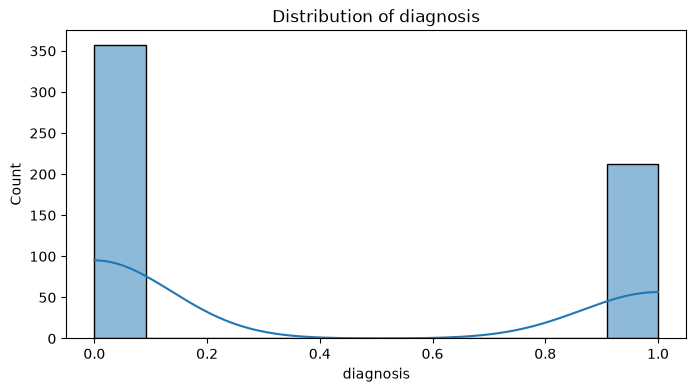

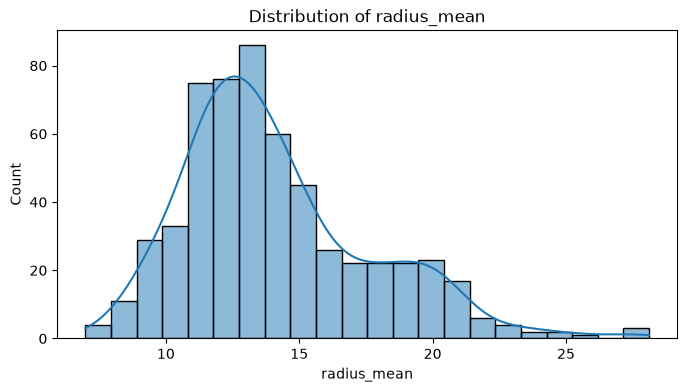

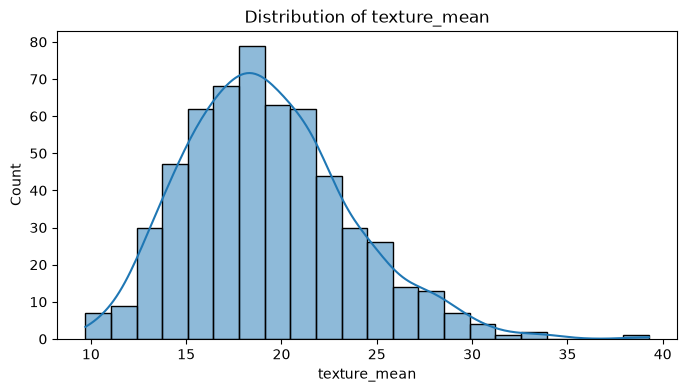

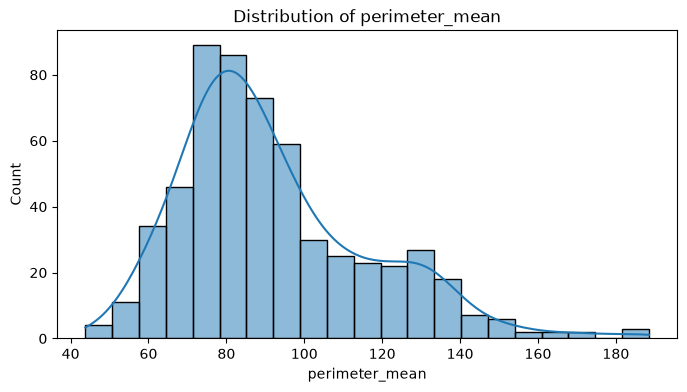

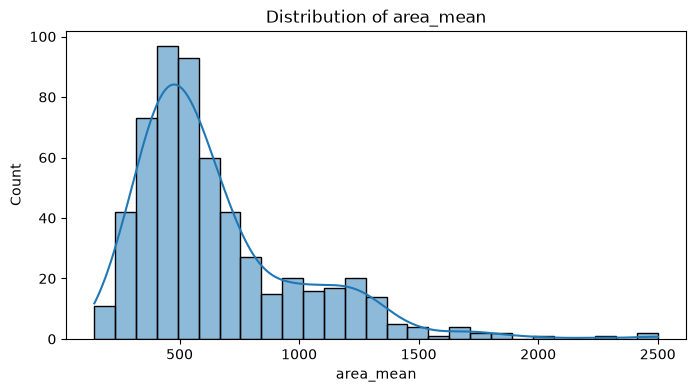

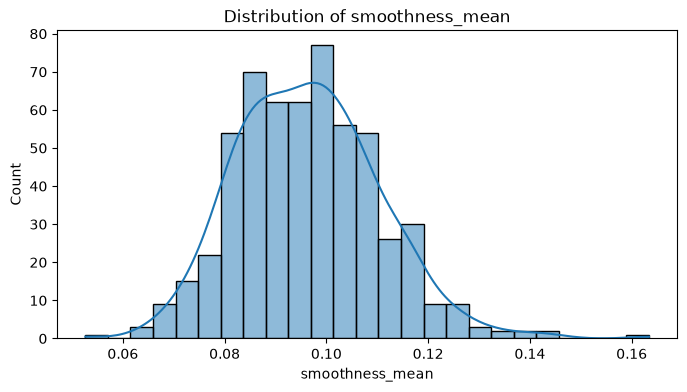

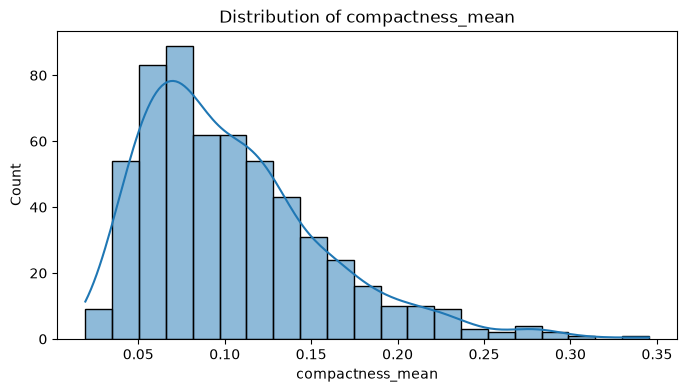

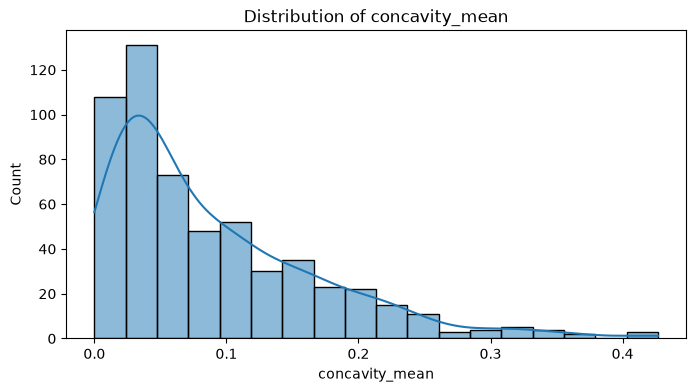

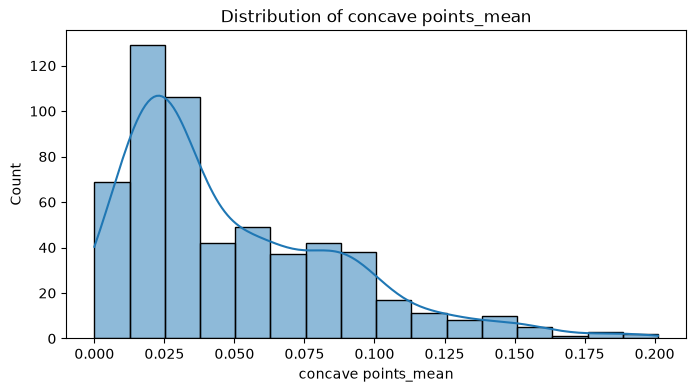

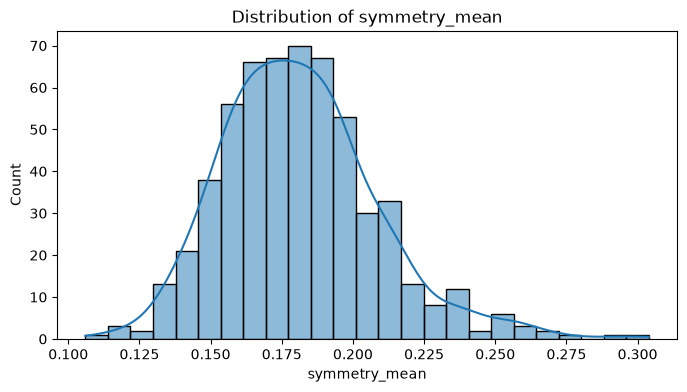

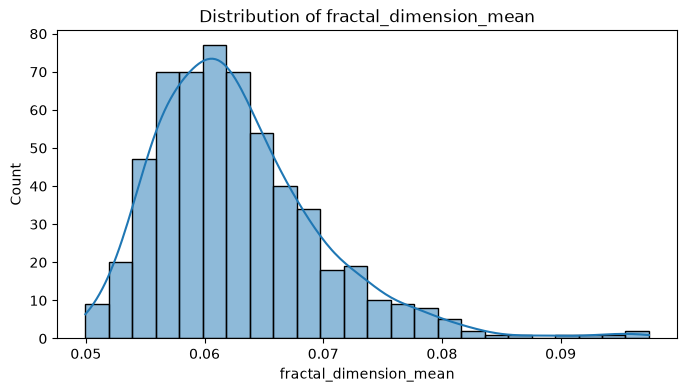

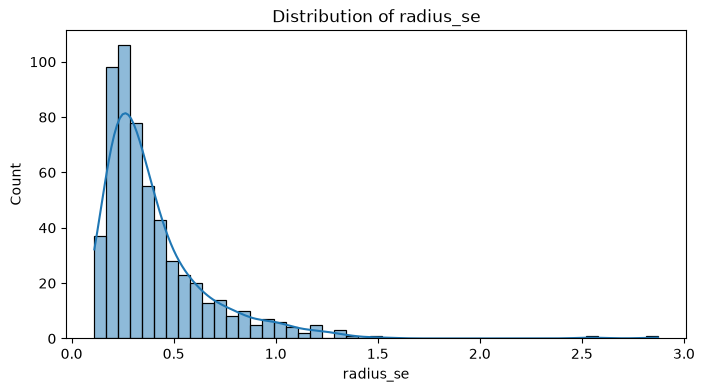

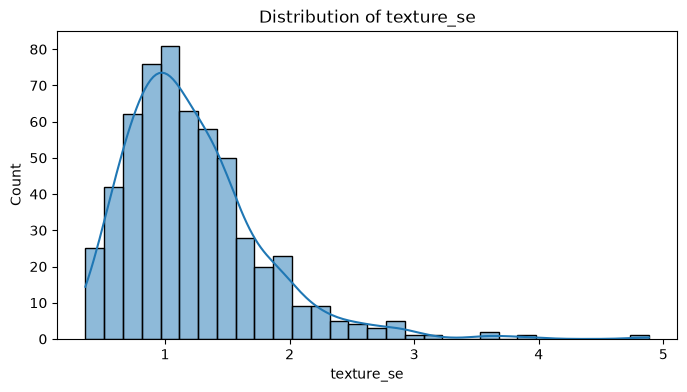

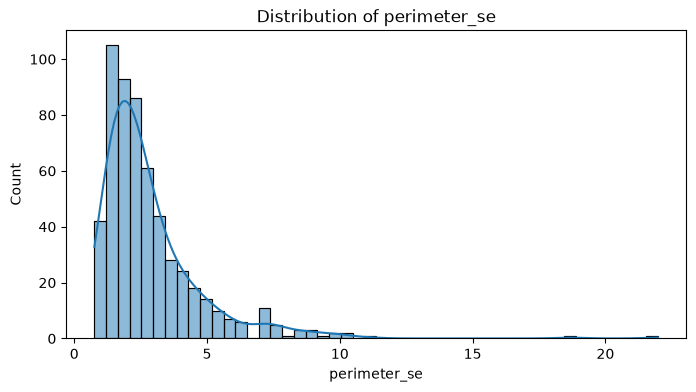

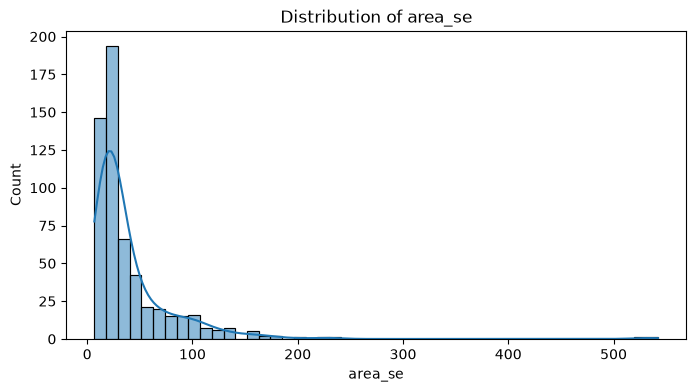

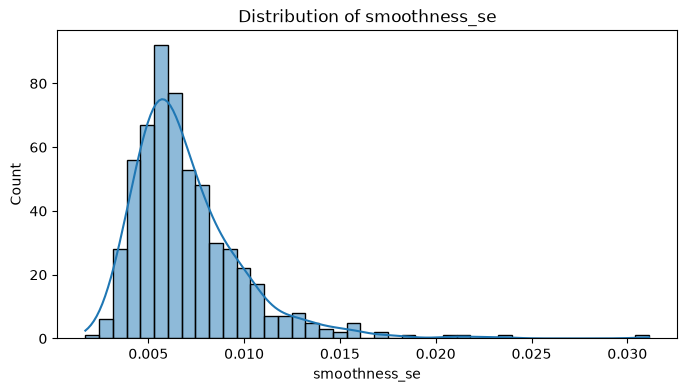

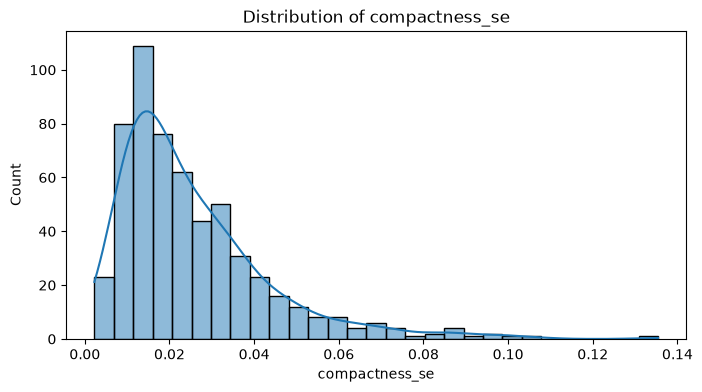

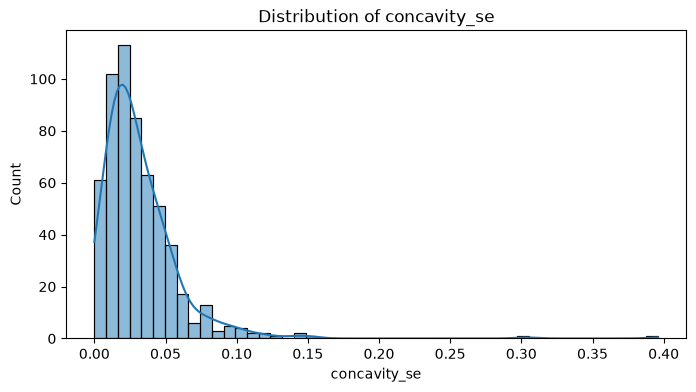

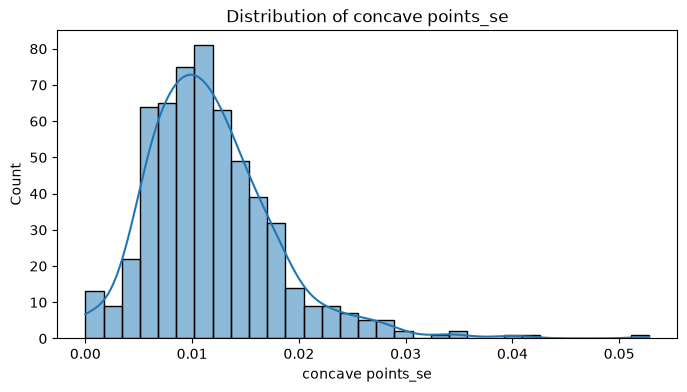

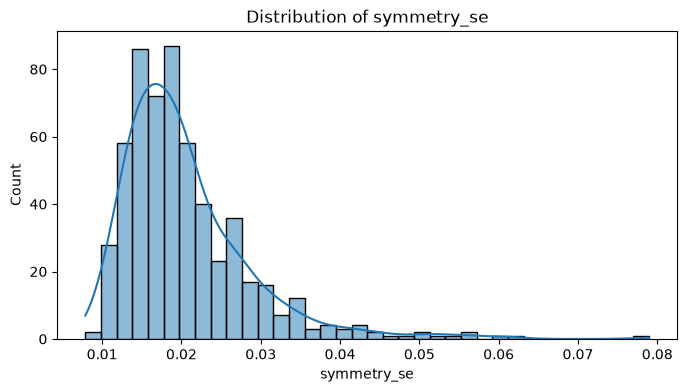

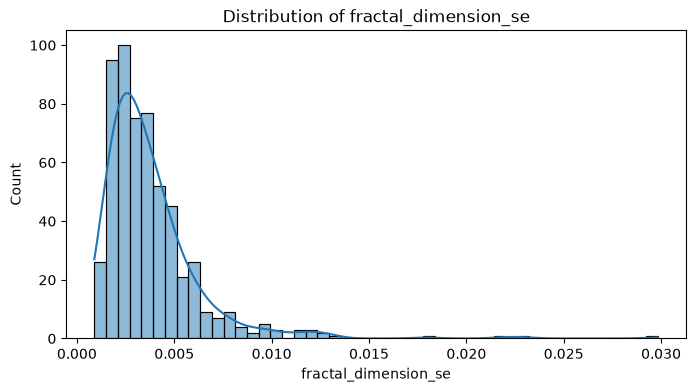

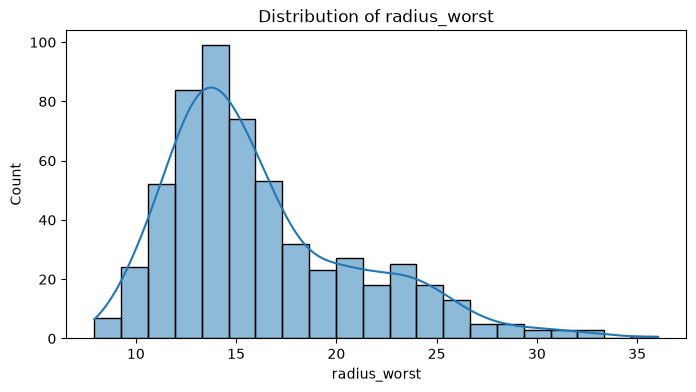

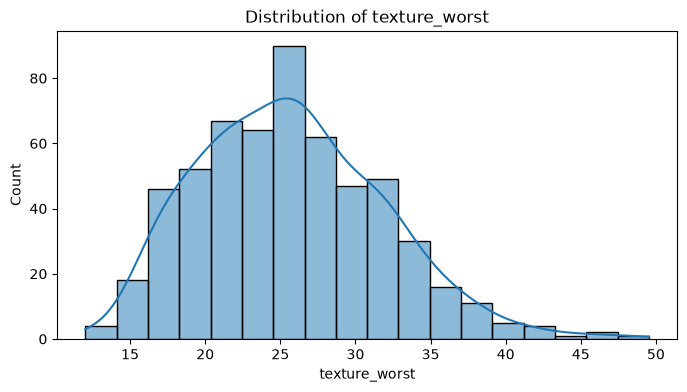

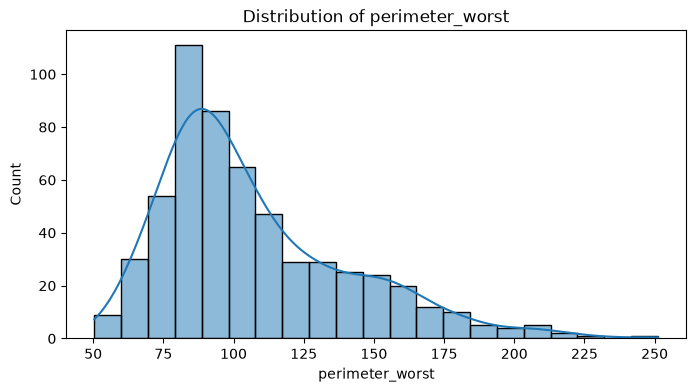

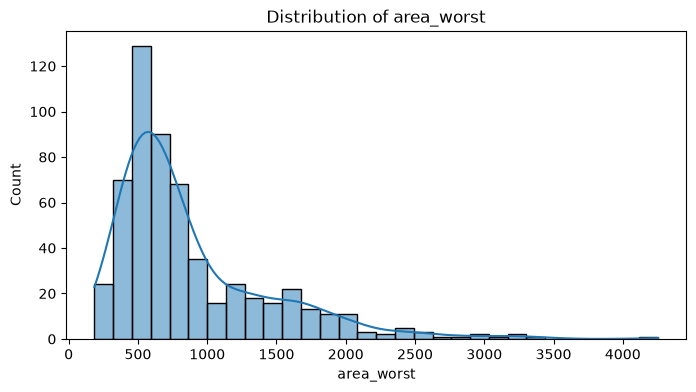

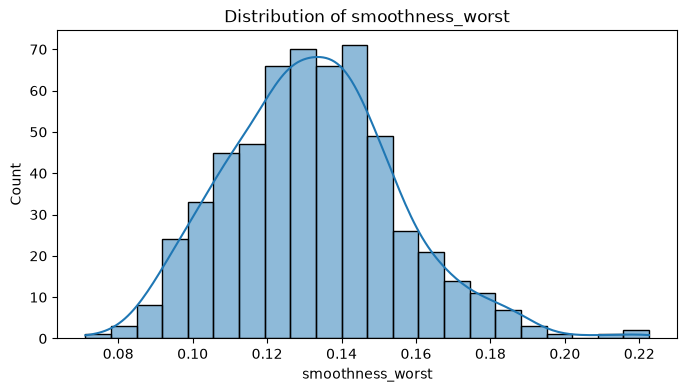

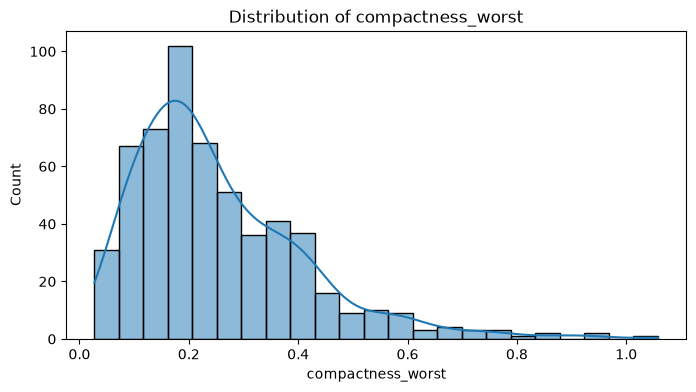

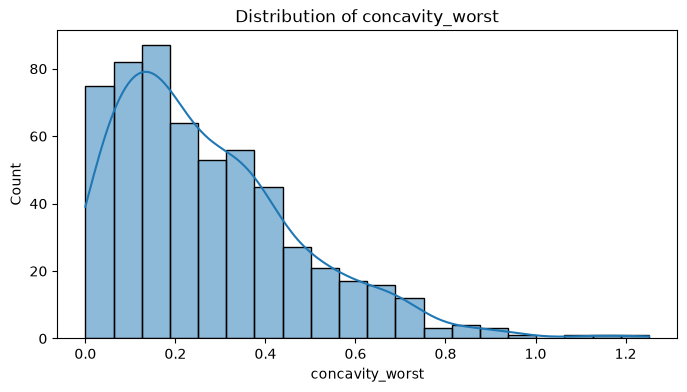

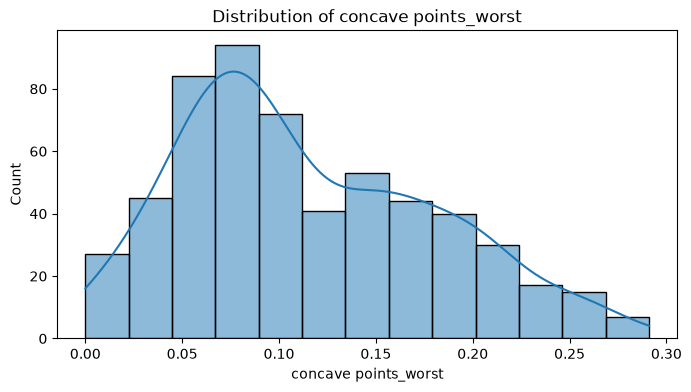

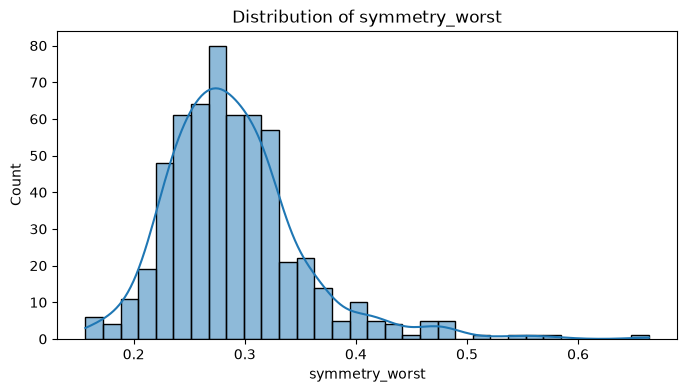

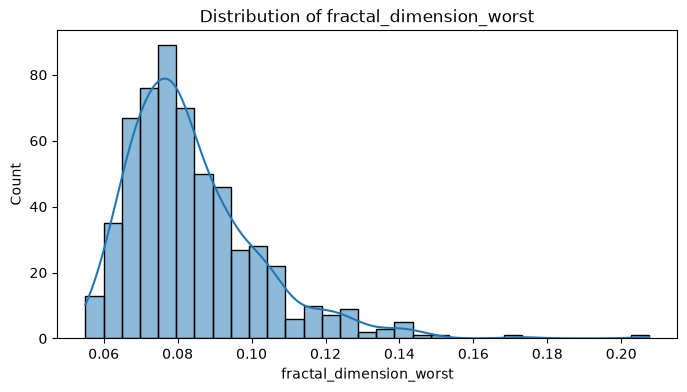

In [143]:
numeric_cols = df.select_dtypes(include=np.number).columns


for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

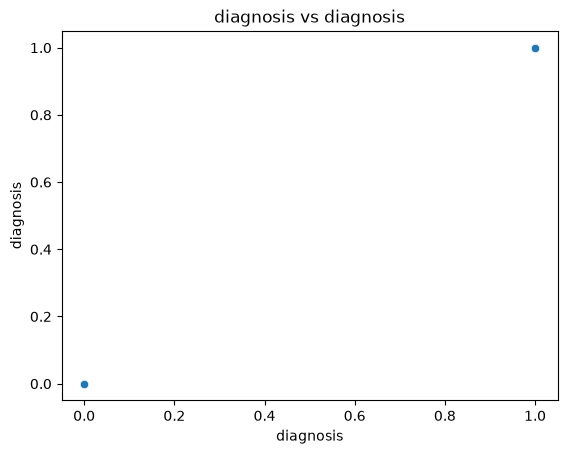

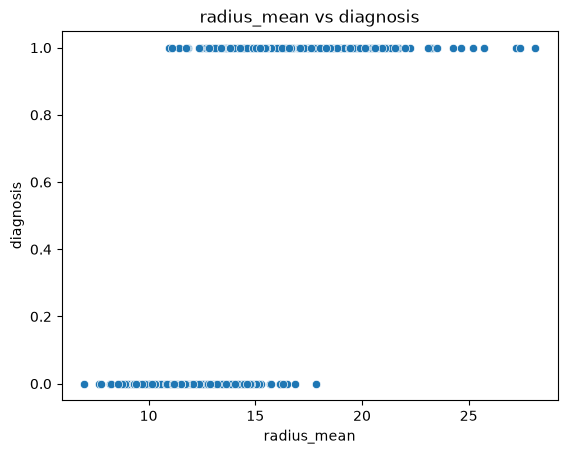

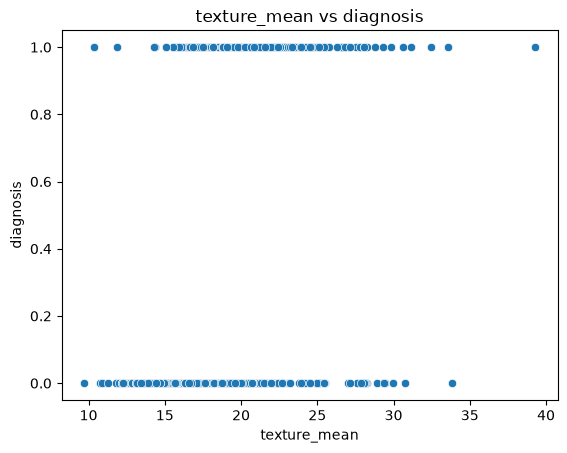

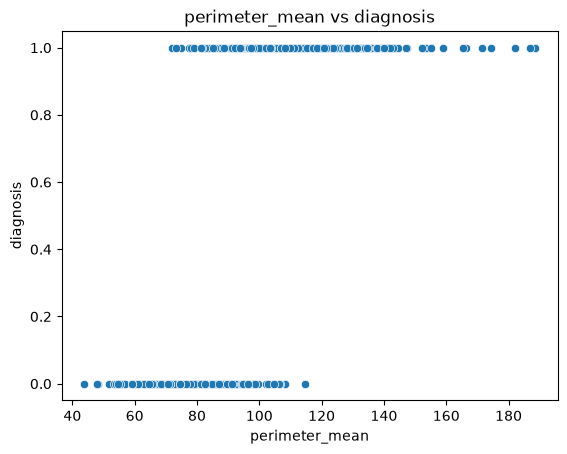

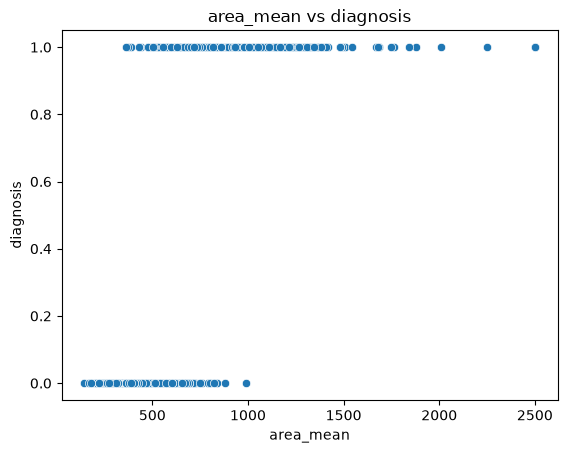

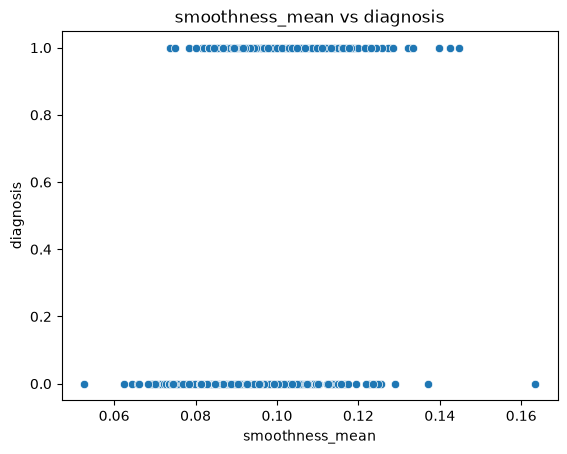

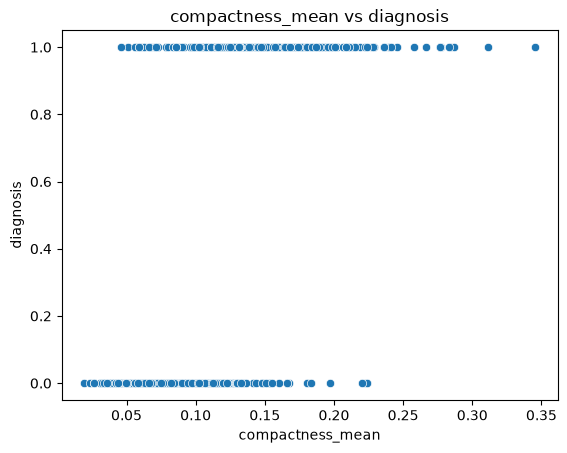

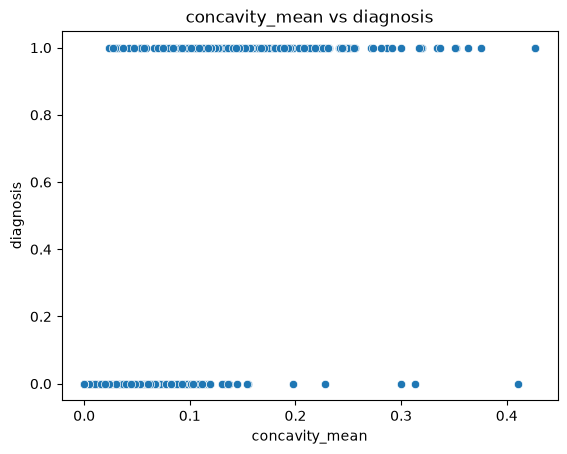

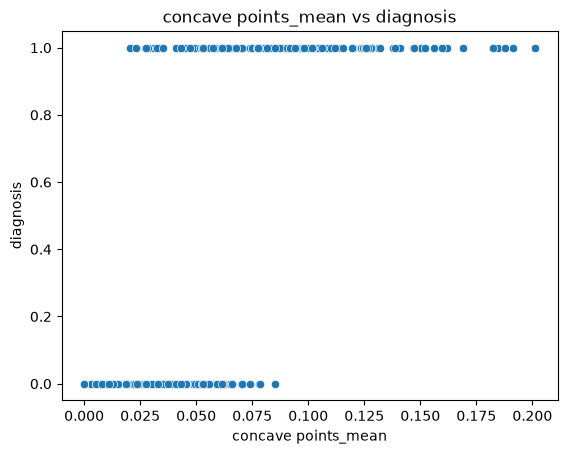

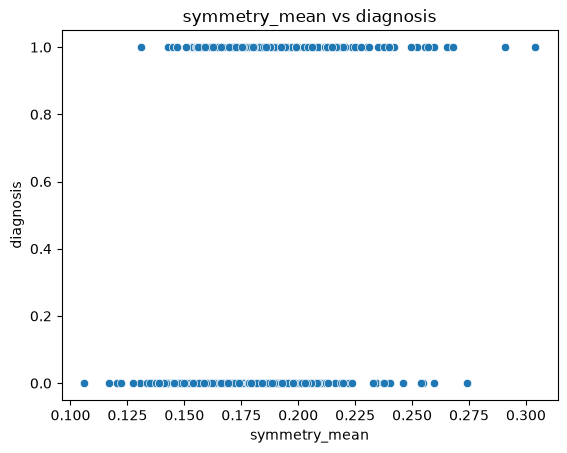

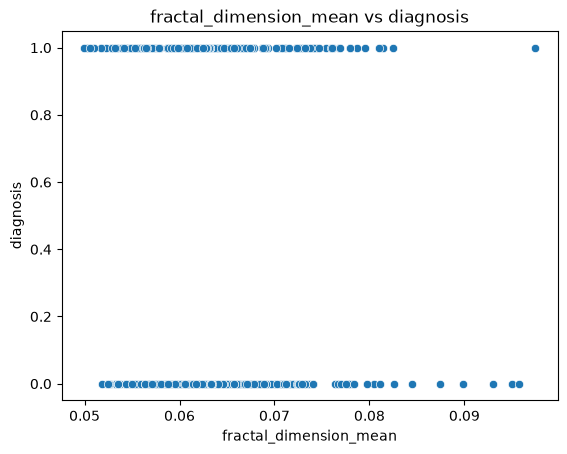

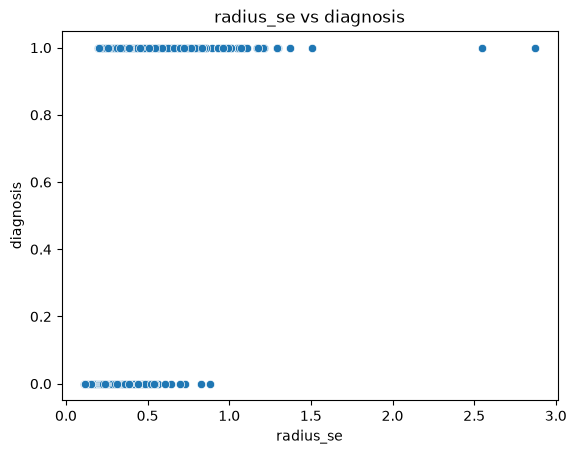

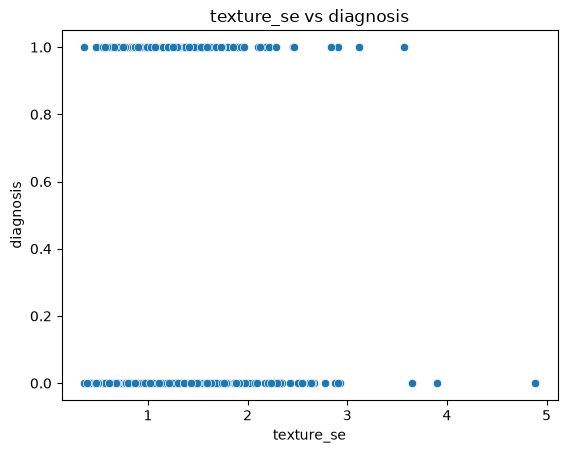

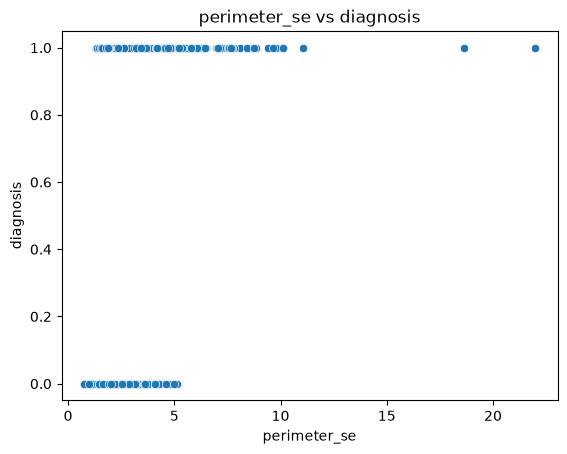

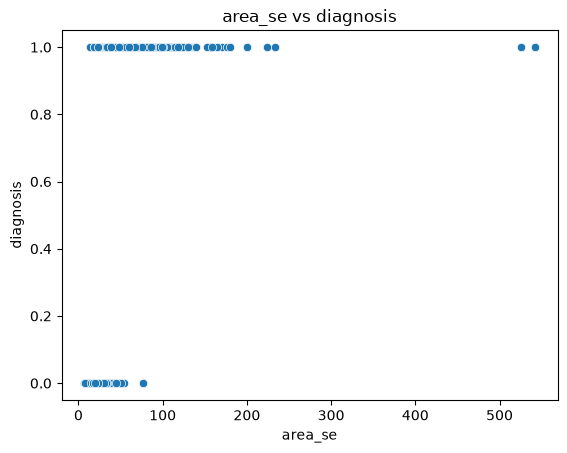

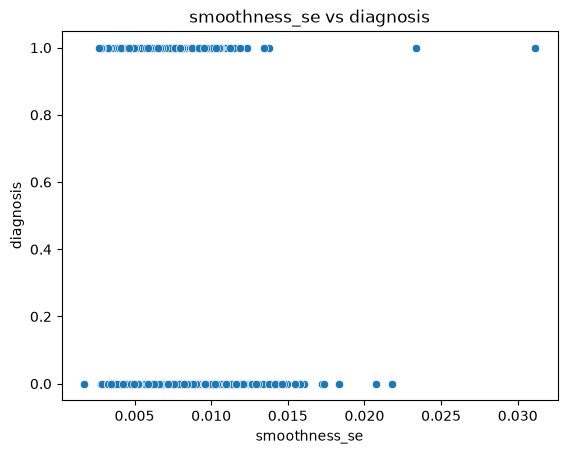

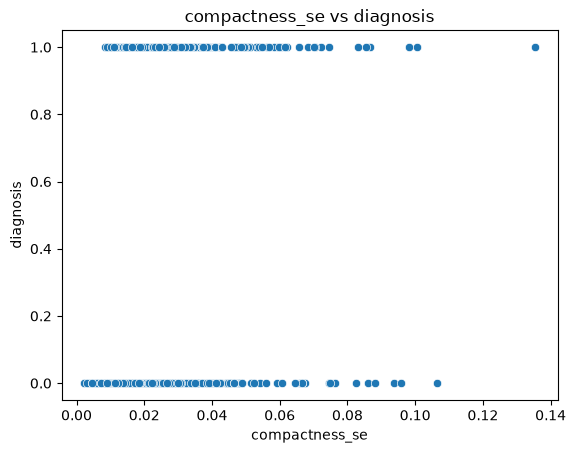

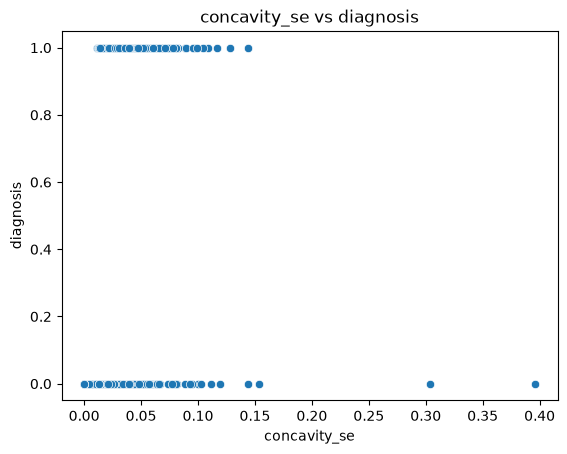

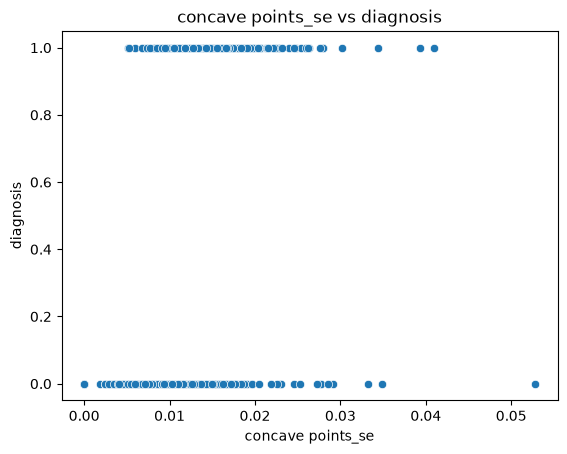

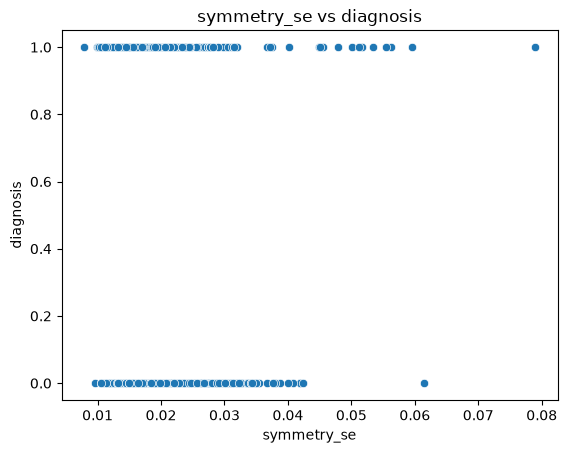

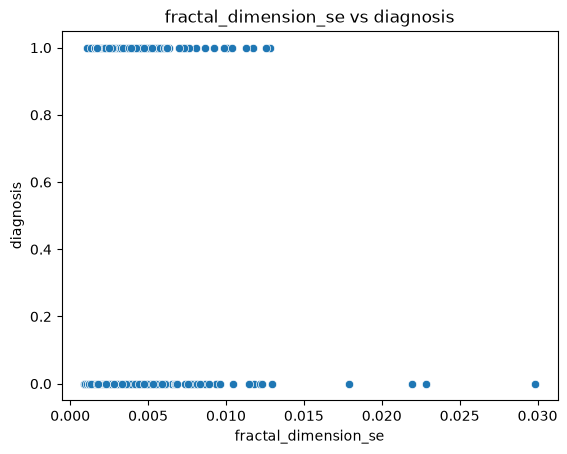

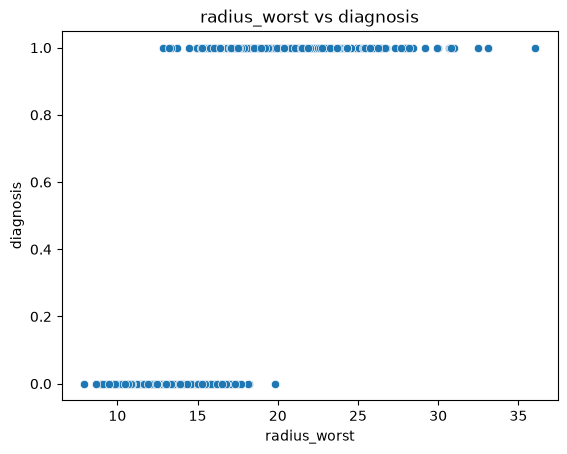

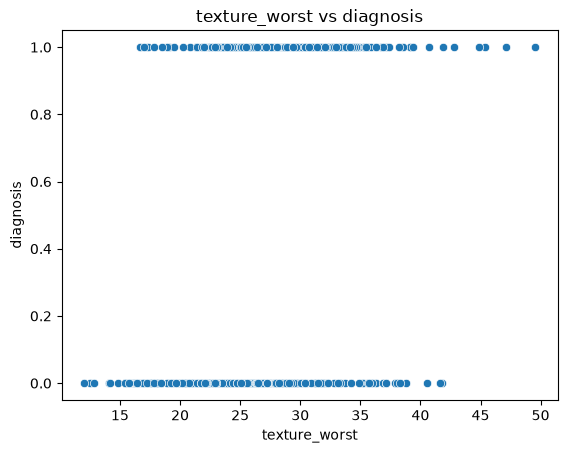

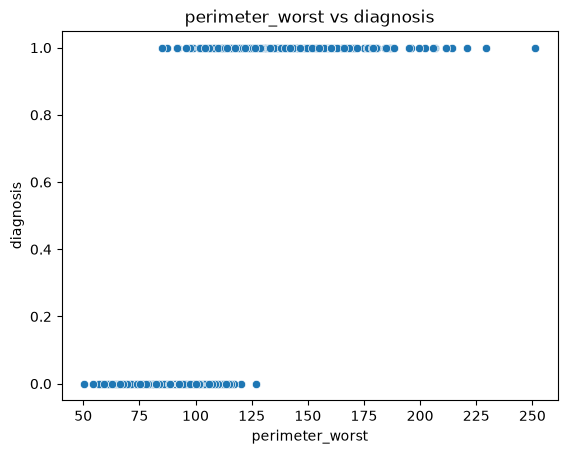

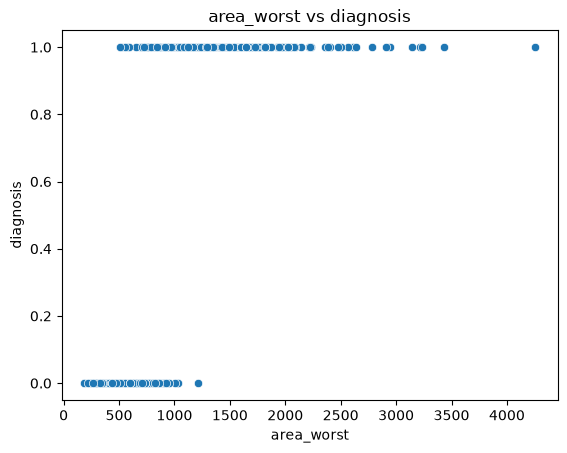

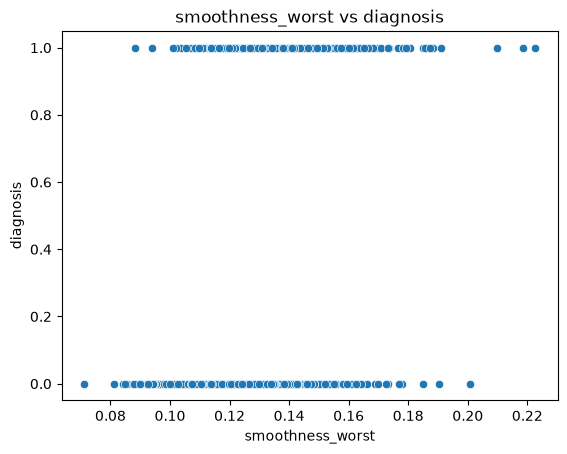

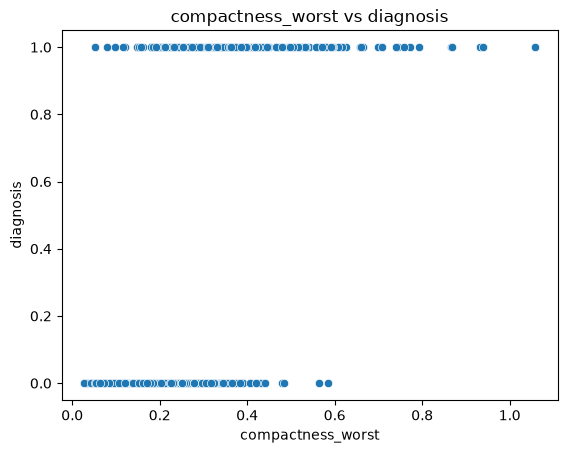

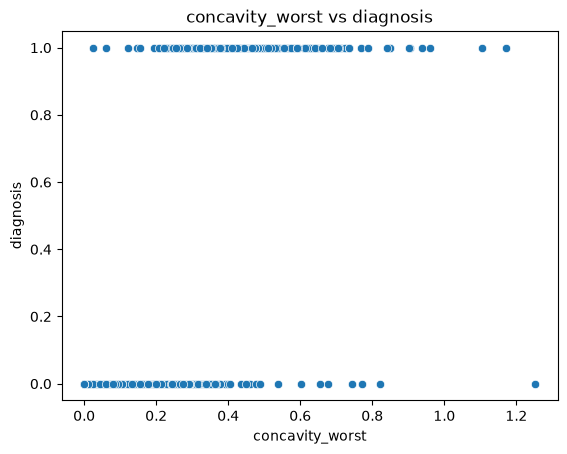

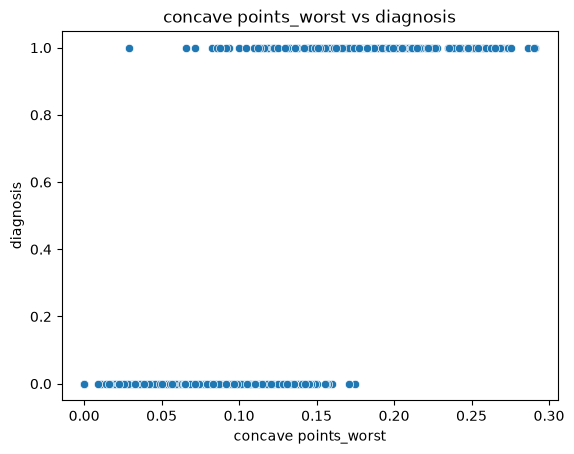

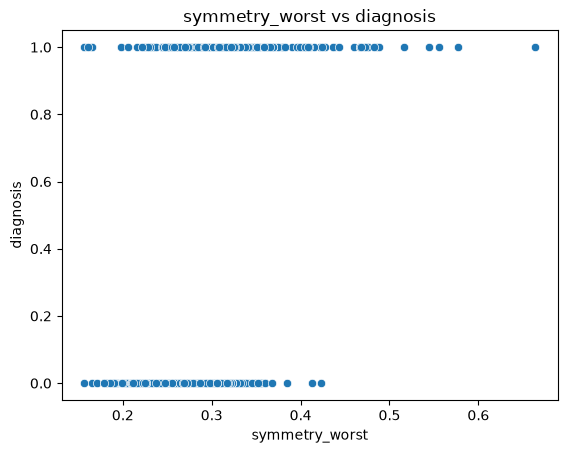

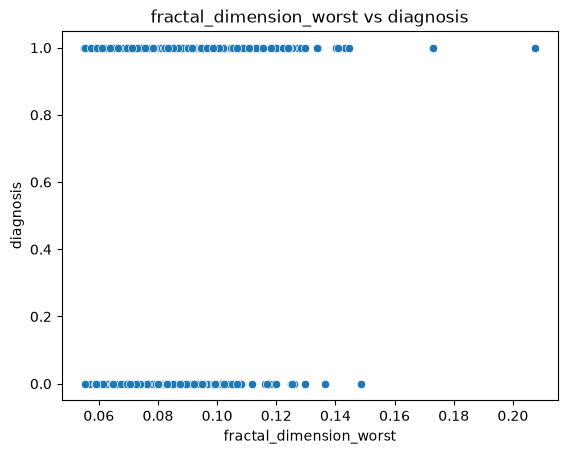

In [144]:

for feature in numeric_cols:
    sns.scatterplot(x=df[feature], y=df["diagnosis"])
    plt.xlabel(feature)
    plt.ylabel("diagnosis")
    plt.title(f"{feature} vs diagnosis")
    plt.show()

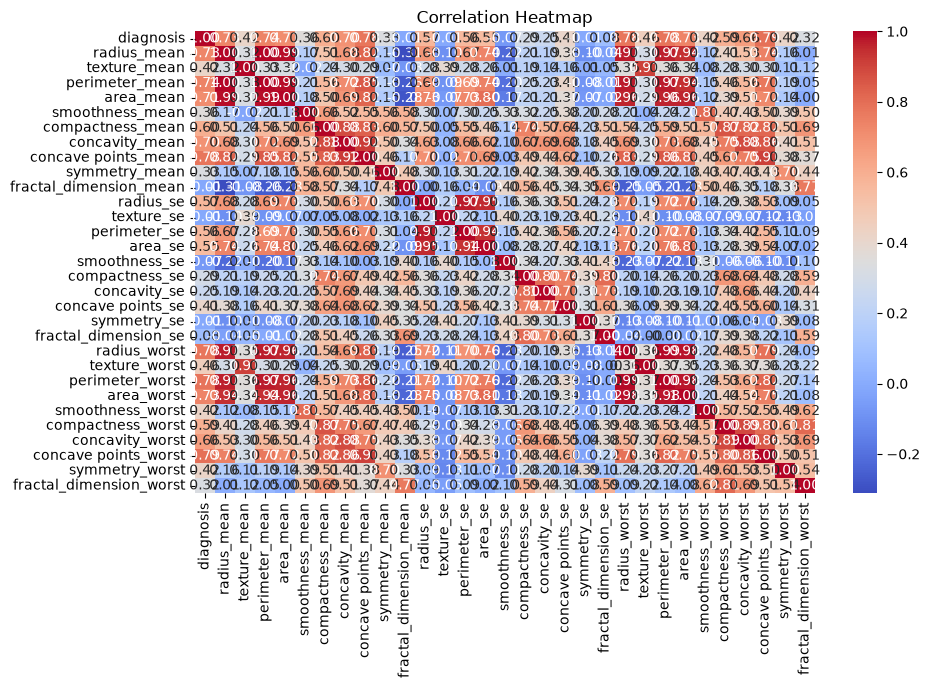

In [145]:
plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

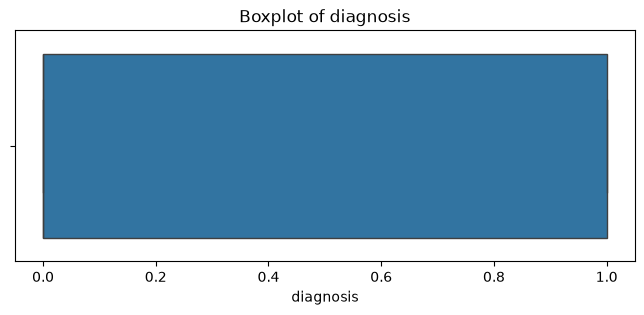

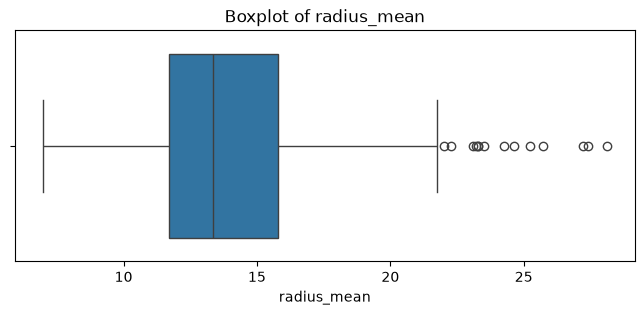

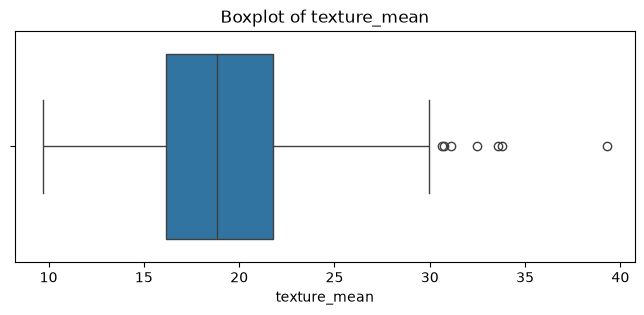

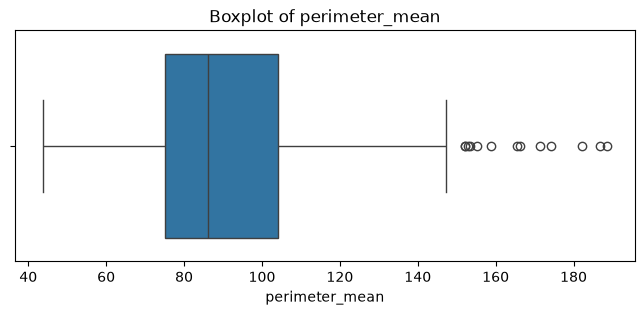

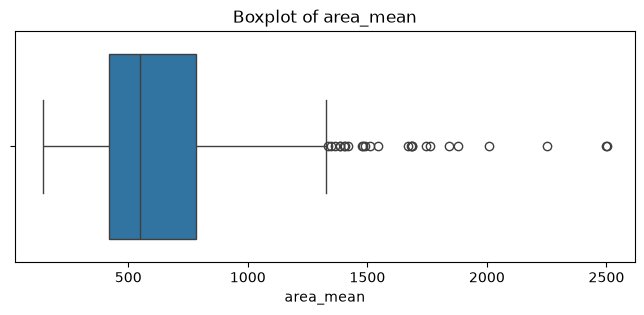

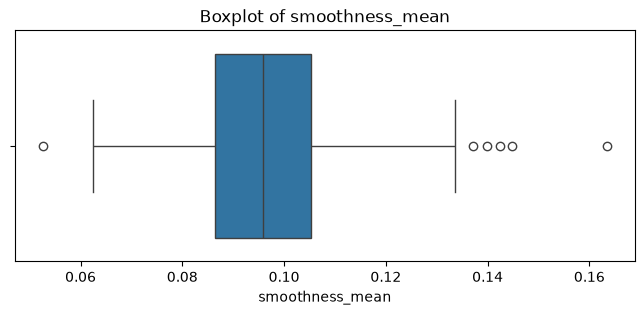

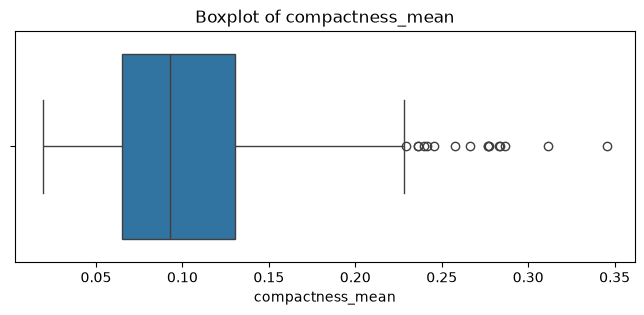

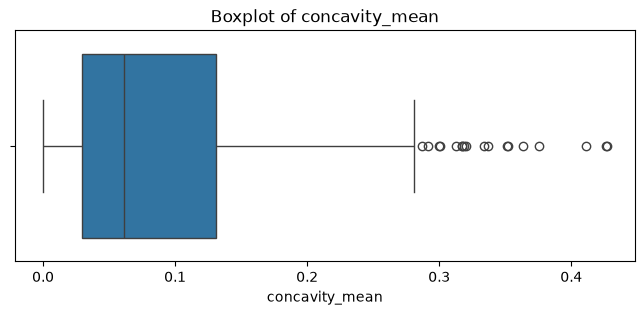

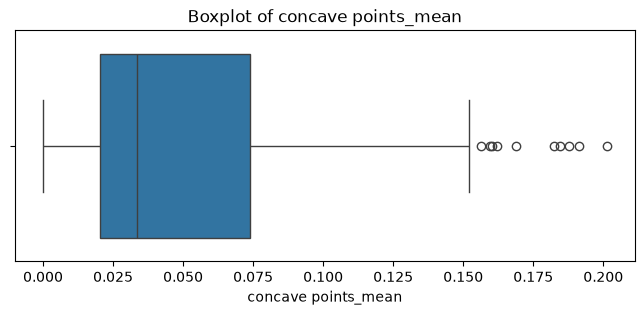

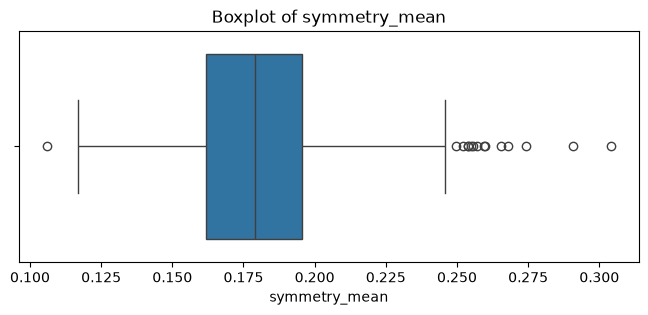

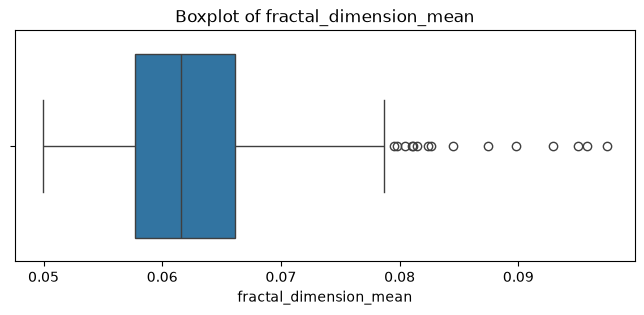

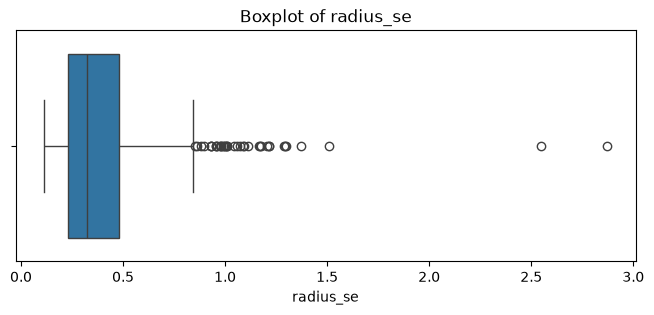

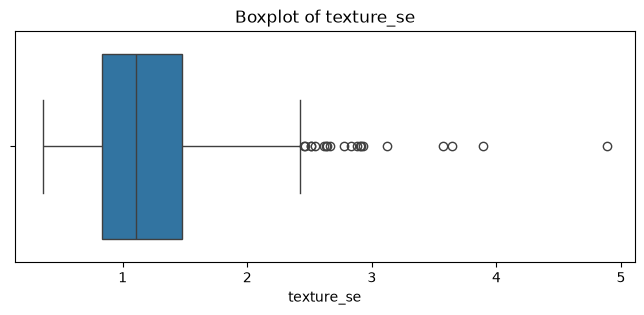

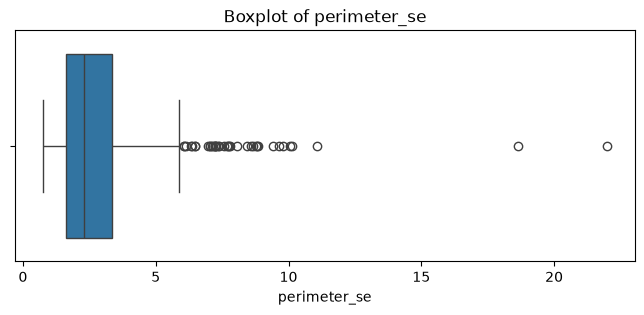

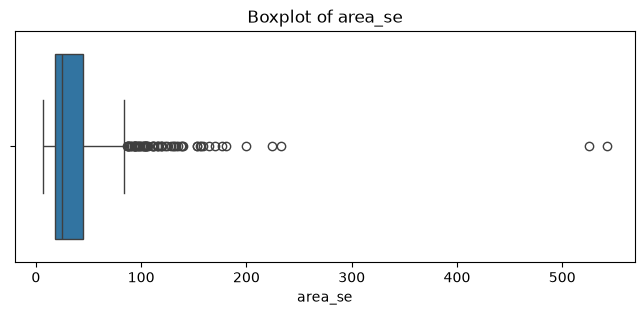

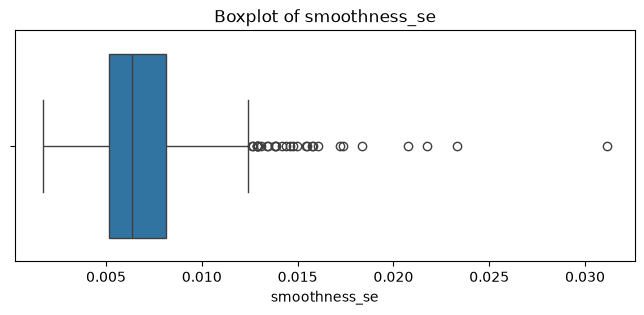

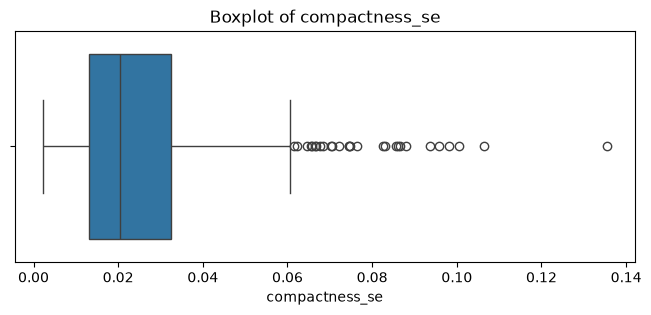

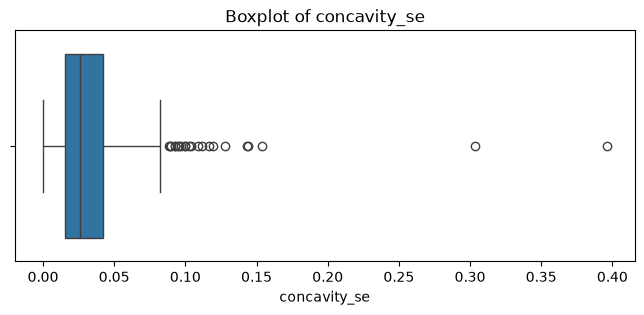

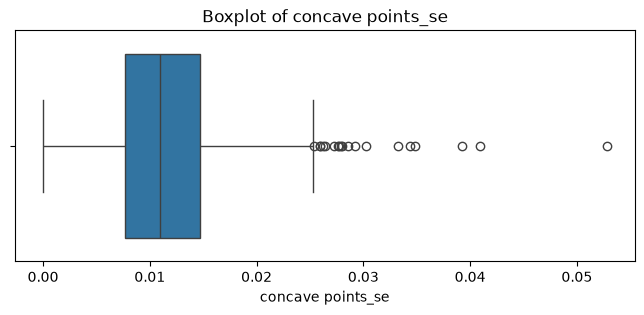

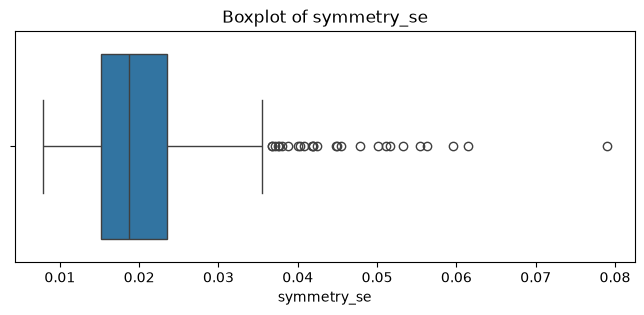

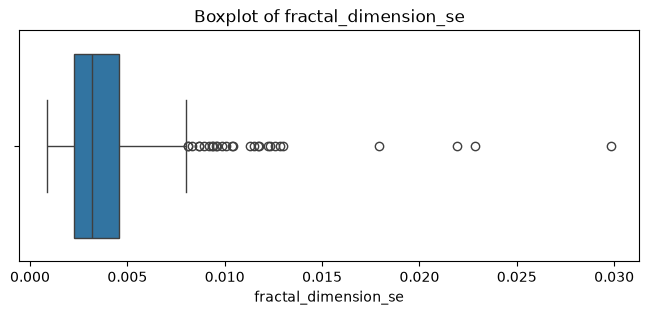

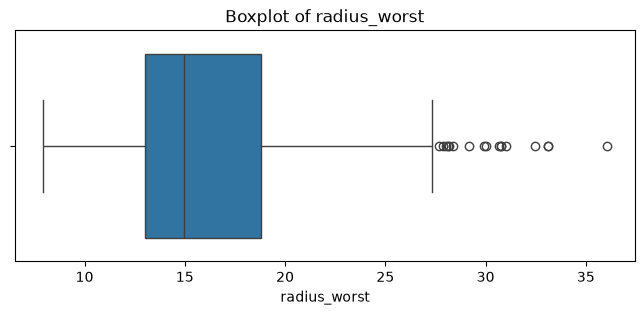

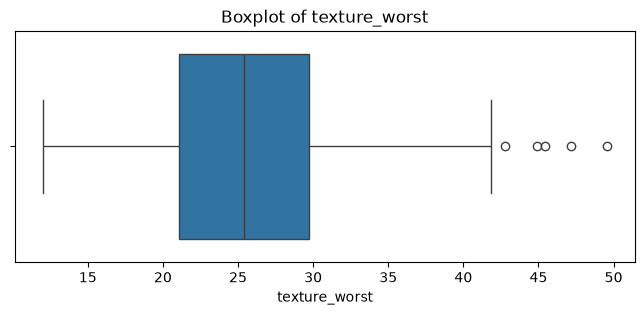

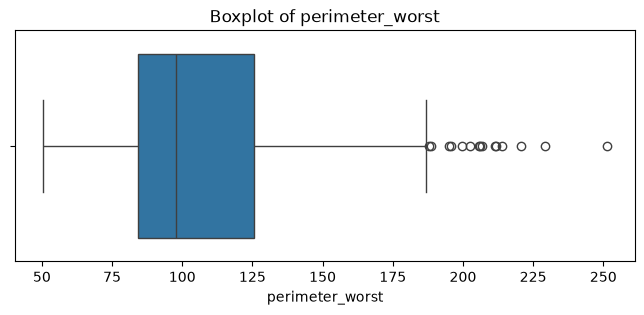

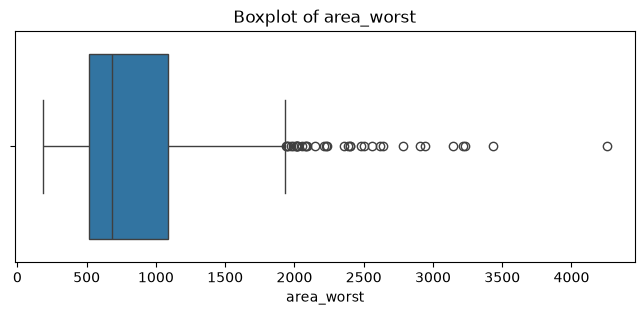

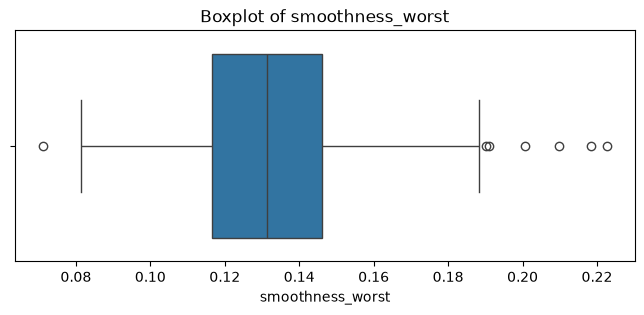

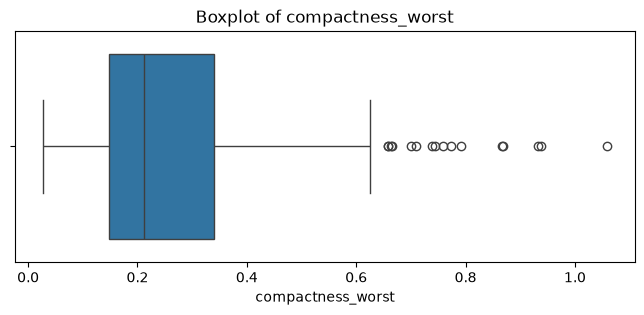

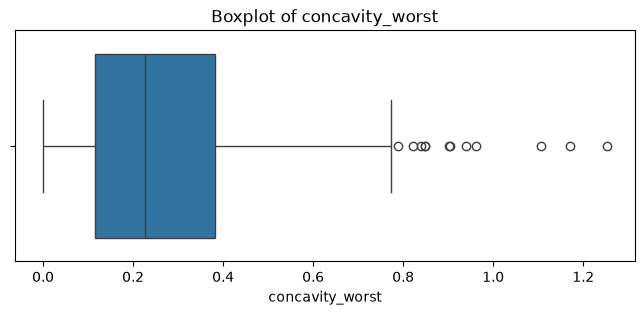

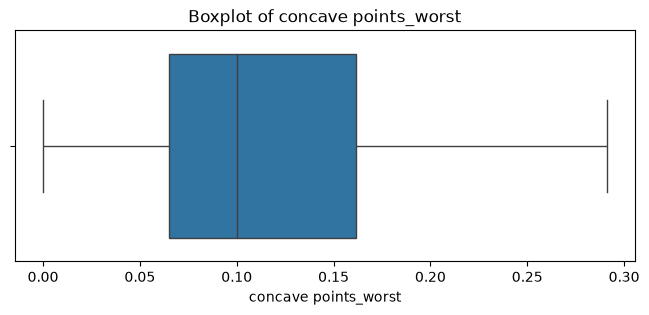

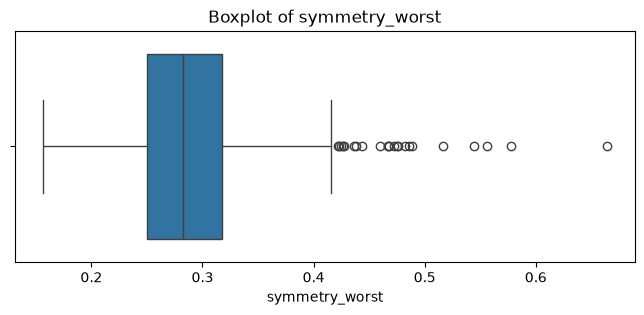

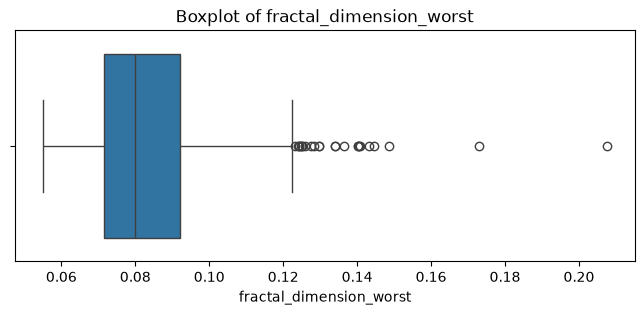

In [146]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in the numerical features.

The IQR is calculated as:

**IQR = Q3 − Q1**

Potential outliers are observations below:

**Q1 − 1.5 × IQR**

or above:

**Q3 + 1.5 × IQR**

These observations will be inspected rather than automatically removed.

In [147]:
numeric_features = df.select_dtypes(include=np.number).columns

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)


diagnosis : 0
radius_mean : 14
texture_mean : 7
perimeter_mean : 13
area_mean : 25
smoothness_mean : 6
compactness_mean : 16
concavity_mean : 18
concave points_mean : 10
symmetry_mean : 15
fractal_dimension_mean : 15
radius_se : 38
texture_se : 20
perimeter_se : 38
area_se : 65
smoothness_se : 30
compactness_se : 28
concavity_se : 22
concave points_se : 19
symmetry_se : 27
fractal_dimension_se : 28
radius_worst : 17
texture_worst : 5
perimeter_worst : 15
area_worst : 35
smoothness_worst : 7
compactness_worst : 16
concavity_worst : 12
concave points_worst : 0
symmetry_worst : 23
fractal_dimension_worst : 24


In [148]:
outlier_limits = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_limits[col] = (lower, upper)

    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier treatment completed.")

limits_df = pd.DataFrame(
    outlier_limits,
    index=["Lower", "Upper"]
).T

display(limits_df)


Outlier treatment completed.


,Lower,Upper
diagnosis,-1.500000,2.500000
radius_mean,5.580000,21.900000
texture_mean,7.725000,30.245000
perimeter_mean,31.775000,147.495000
area_mean,-123.300000,1326.300000
smoothness_mean,0.057975,0.133695
compactness_mean,-0.033300,0.228620
concavity_mean,-0.122150,0.282410
concave points_mean,-0.060225,0.154535
symmetry_mean,0.111200,0.246400


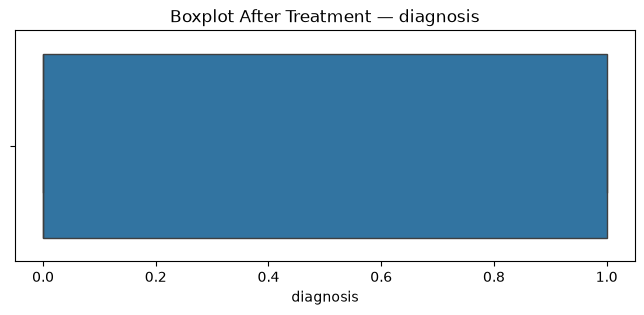

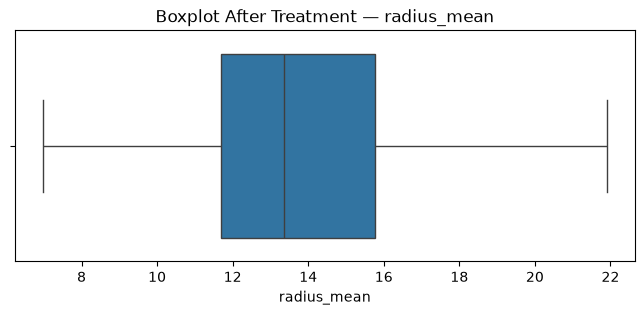

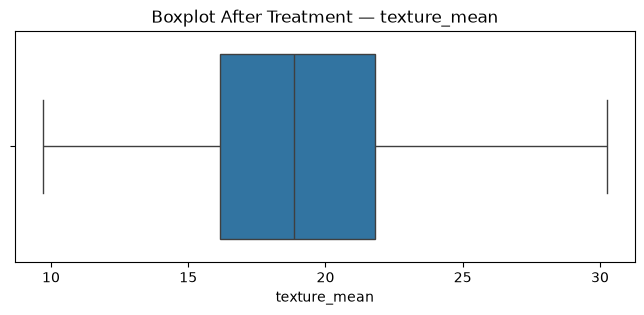

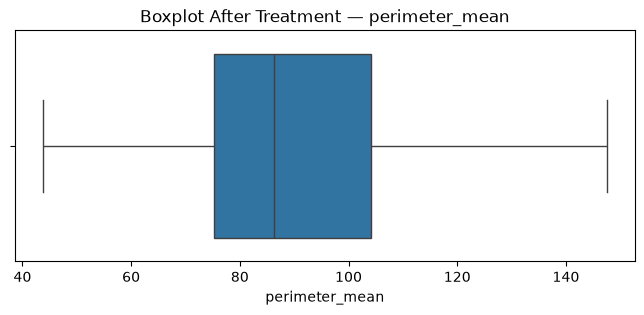

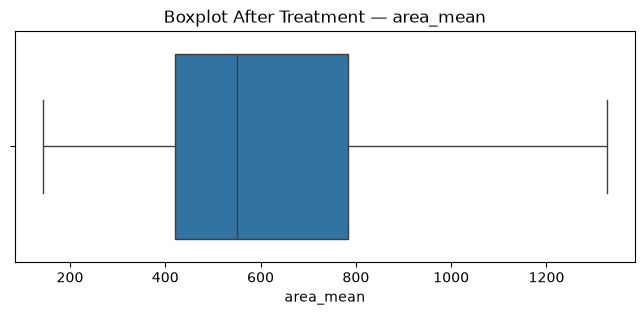

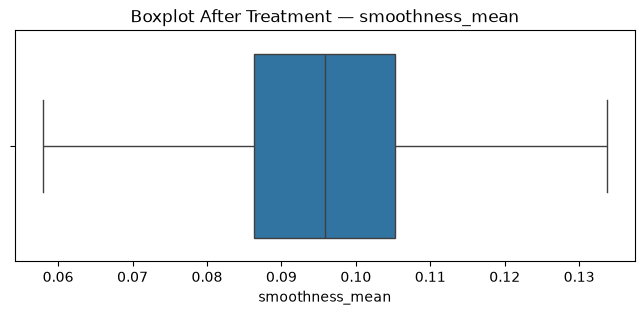

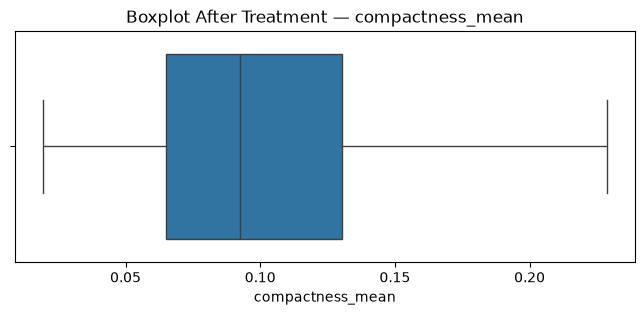

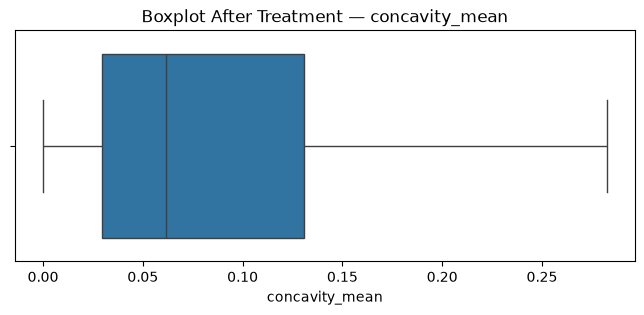

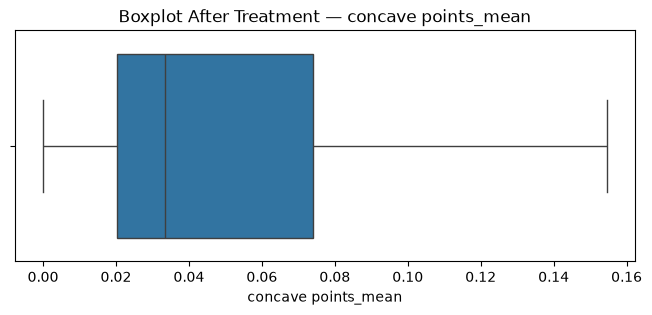

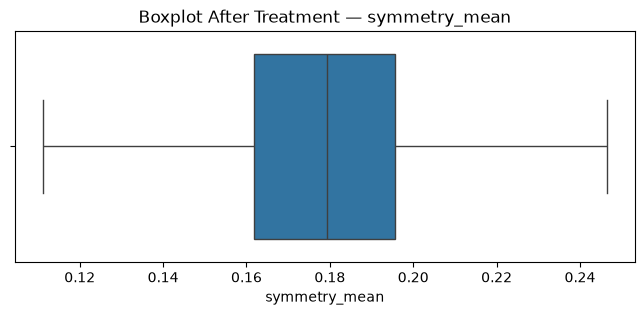

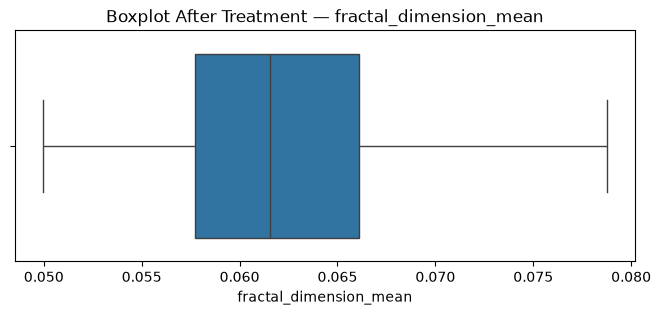

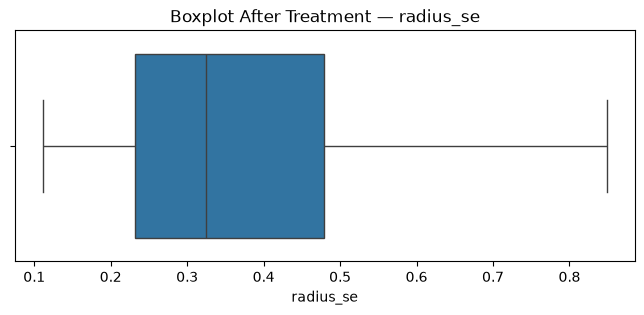

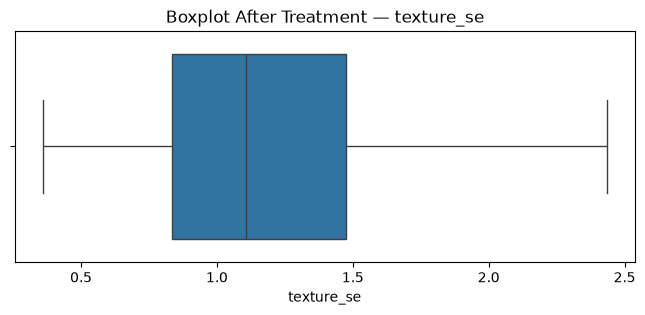

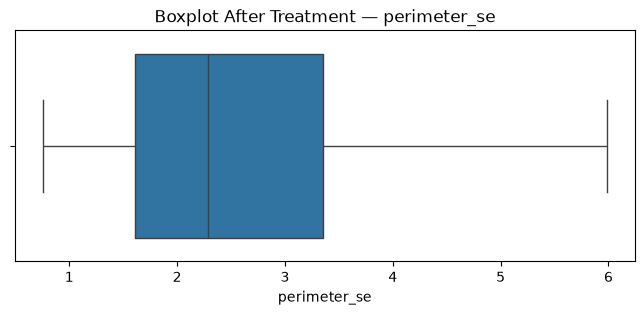

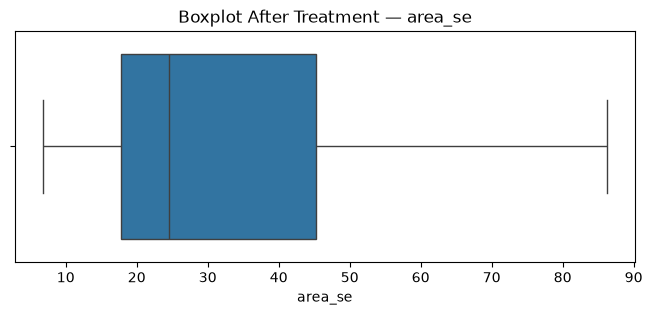

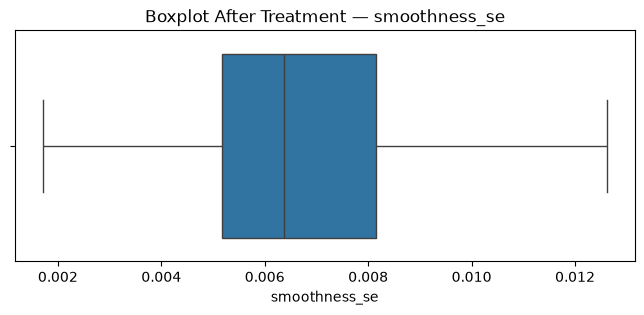

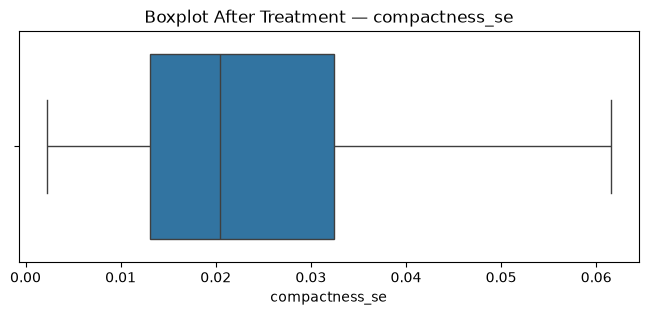

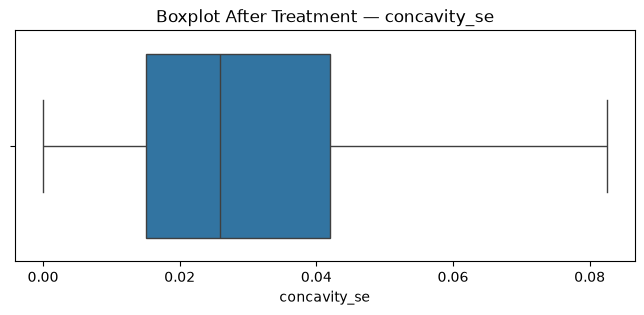

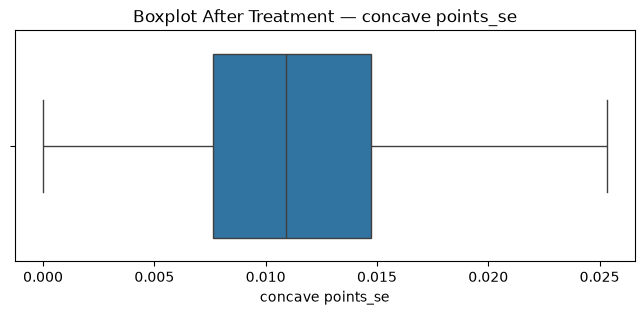

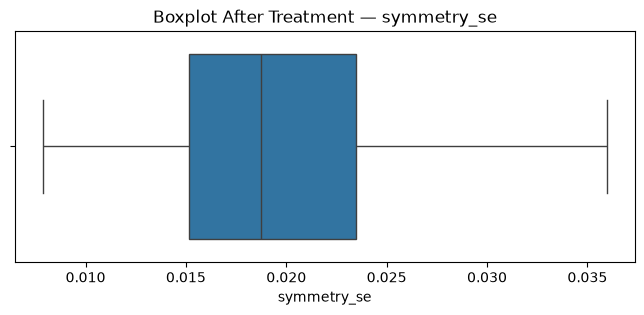

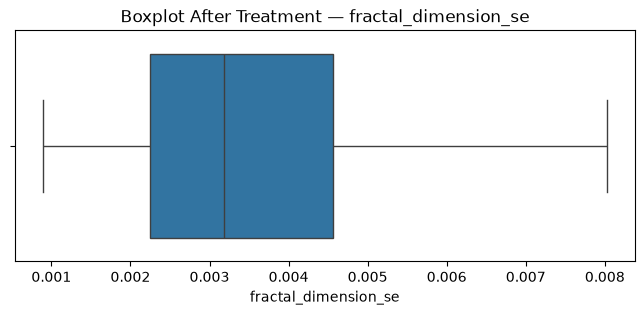

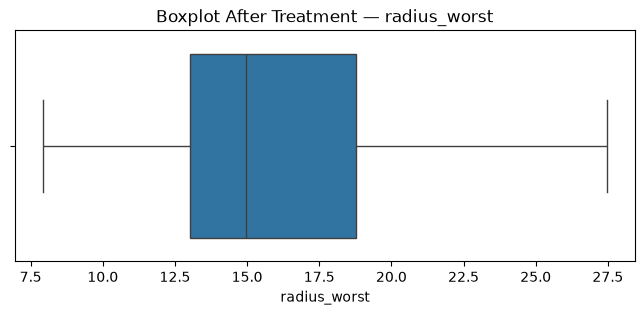

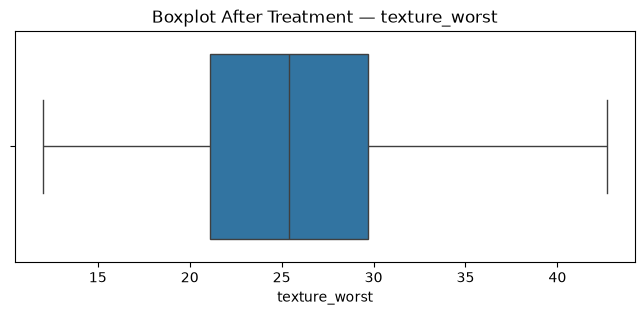

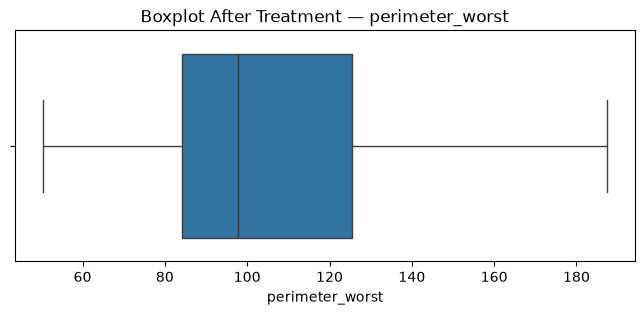

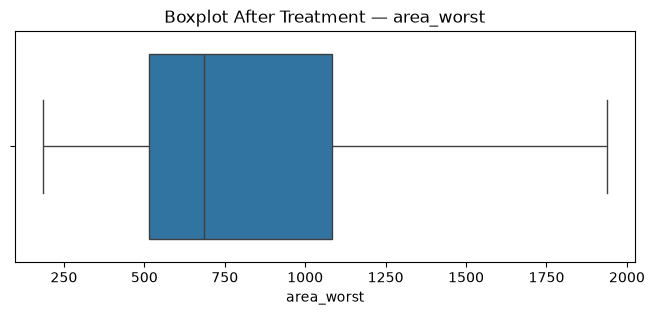

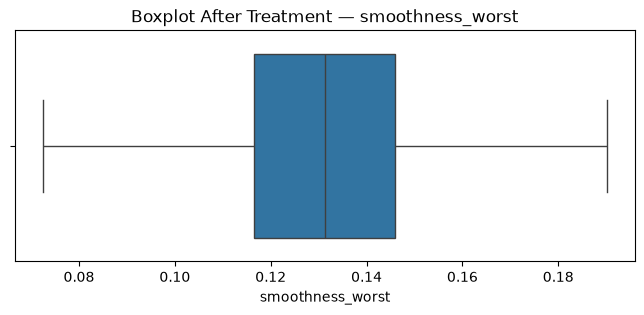

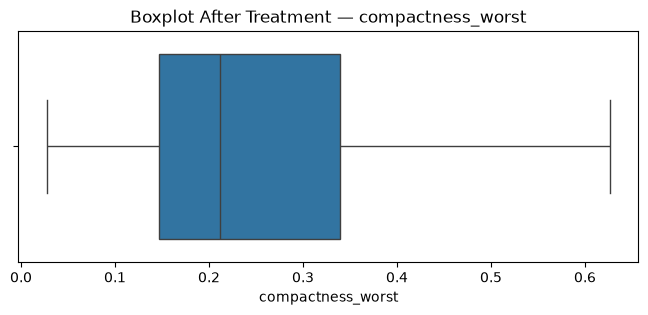

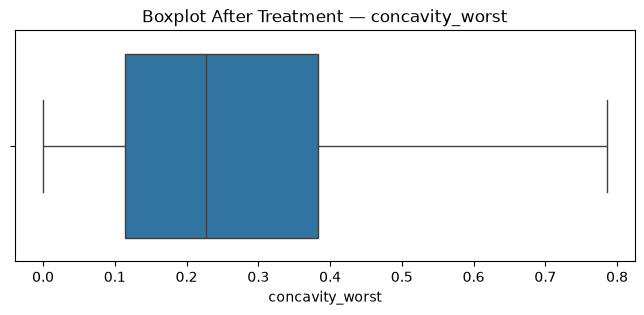

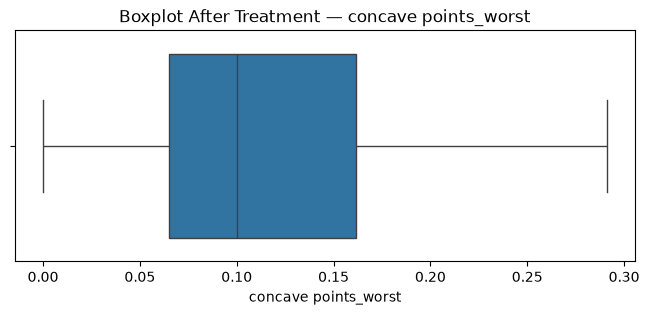

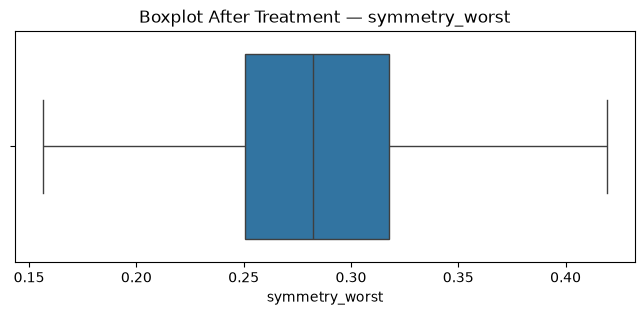

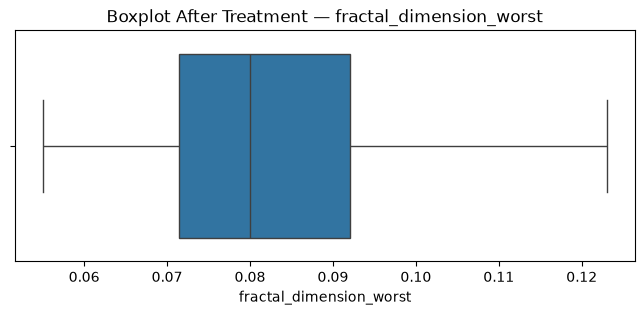

In [149]:
for col in numeric_features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot After Treatment — {col}")
    plt.show()

In [150]:
numerical_features = x.select_dtypes(include='number').columns.tolist()


In [151]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


numerical_transformer=Pipeline(
    steps=[
        ('scaler',StandardScaler())
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
    ]
)


# Part 5 — Train/Test Split

We split the dataset into:

- **80% training data**
- **20% testing data**

The split is performed before fitting preprocessing transformations. This ensures that information from the test set is not used to learn the preprocessing parameters and helps prevent **data leakage**.

In [152]:
from sklearn.model_selection import train_test_split

x=df.drop(columns=['diagnosis'])
y=df['diagnosis']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


# Part 6 — Train the Logistic Regression Model

Logistic Regression is used as the classification model.

The model is trained using the training data after applying the preprocessing pipeline.

 Numerical Features

1. StandardScaler

In [153]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


numerical_transformer=Pipeline(
    steps=[
        ('scaler',StandardScaler())
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
    ]
)

In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline # Import Pipeline for clarity

#Create The LR Model
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression())
    ]
)

#Train The Model In Training Data
lr_model.fit(x_train, y_train)

y_predict = lr_model.predict(x_test)


# Part 7 — Model Evaluation

After training the Logistic Regression model, we evaluate its performance on the test data using classification metrics and the confusion matrix.

The main metrics are:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

The confusion matrix is also used to understand the types of correct and incorrect predictions.

In [155]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

